In [1]:
import kagglehub
import pandas as pd
import os
import glob

# 1. Download the dataset
print("Downloading dataset...")
path = kagglehub.dataset_download("guriya79/student-mental-health-and-academic-pressure")
print("Path to dataset files:", path)

# 2. Find the CSV file automatically
# We use glob to find any file ending in .csv in that folder
csv_files = glob.glob(os.path.join(path, "*.csv"))

if csv_files:
    file_path = csv_files[0]
    print(f"File found: {file_path}")
    # Load into Pandas
    df = pd.read_csv(file_path)
    print("Data loaded successfully!")
else:
    print("No CSV file found in the downloaded folder.")

# Show the first 5 rows to understand the data
print("\n--- First 5 Rows of Data ---")
print(df.head())

# Show data types and column names
print("\n--- Data Info ---")
print(df.info())

c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 1.12k/1.12k [00:00<00:00, 774kB/s]

Extracting files...
Path to dataset files: C:\Users\HP\.cache\kagglehub\datasets\guriya79\student-mental-health-and-academic-pressure\versions\1
File found: C:\Users\HP\.cache\kagglehub\datasets\guriya79\student-mental-health-and-academic-pressure\versions\1\Student_Mental_Health_Academic_Pressure_2025.csv - Form Responses 1.csv
Data loaded successfully!

--- First 5 Rows of Data ---
            Timestamp Age Group   Gender\n     Current Education Level    \
0  12/13/2025 6:18:33     15–18       Female                     College   
1  12/13/2025 6:24:50     15–18         Male                     College   
2  12/13/2025 6:29:50     15–18       Female                  University   
3  12/13/2025 7:36:26       27+         Male                       Other   
4  12/13/2025 8:01:20     15–18       Female                     College   

     How much academic pressure do you feel?    \
0                                            4   
1                                            4   
2     

In [2]:
# 1. Check for missing values
print("\n--- Missing Values Before Cleaning ---")
missing_values = df.isnull().sum()
print(missing_values)

# 2. Solve the Missing Value Problem
# Strategy: 
# - For categorical (text) data, we fill missing values with the 'Mode' (most frequent answer).
# - For numerical data, we fill with the 'Median' (to avoid outliers skewing the average).

for column in df.columns:
    if df[column].isnull().sum() > 0:
        # Check if column is numerical
        if pd.api.types.is_numeric_dtype(df[column]):
            fill_value = df[column].median()
            df[column] = df[column].fillna(fill_value)
            print(f"Filled missing numerical values in '{column}' with median: {fill_value}")
        # Otherwise it's categorical (text)
        else:
            fill_value = df[column].mode()[0]
            df[column] = df[column].fillna(fill_value)
            print(f"Filled missing categorical values in '{column}' with mode: {fill_value}")

# Verify cleaning
print("\n--- Missing Values After Cleaning ---")
print(df.isnull().sum())


--- Missing Values Before Cleaning ---
Timestamp                                                0
Age Group                                                0
  Gender\n                                               0
  Current Education Level                                0
  How much academic pressure do you feel?                0
 How often do you feel stressed due to studies?          0
  How many hours do you sleep on average per night?      0
  What is the main cause of your academic stress?        0
dtype: int64

--- Missing Values After Cleaning ---
Timestamp                                                0
Age Group                                                0
  Gender\n                                               0
  Current Education Level                                0
  How much academic pressure do you feel?                0
 How often do you feel stressed due to studies?          0
  How many hours do you sleep on average per night?      0
  What is the main caus

In [4]:
# --- FIX COLUMN NAMES ---

# 1. First, remove any accidental spaces at the start/end of names (e.g. 'Gender ')
df.columns = df.columns.str.strip()

# 2. Print the actual column names so you can see them
print("Original Columns:", df.columns.tolist())

# 3. Rename the long questions to short, easy names
# This maps the "Question" -> "Short Name"
df = df.rename(columns={
    # Format: "Exact Name in CSV" : "New Name"
    'How much academic pressure do you feel?': 'Academic Pressure Level',
    'How often do you feel stressed due to studies?': 'Frequency of Academic Stress',
    'How many hours do you sleep on average per night?': 'Average Sleep Duration',
    'What is the main cause of your academic stress?': 'Main Cause of Academic Stress',
    'Choose your gender': 'Gender',       # Possible name 1
    'What is your gender?': 'Gender',     # Possible name 2
    'Your Gender': 'Gender'               # Possible name 3
})

# 4. Verify the fix
print("\nNew Column Names:", df.columns.tolist())

# Check if 'Gender' is now valid
if 'Gender' in df.columns:
    print("✅ Success: 'Gender' column is ready!")
else:
    print("❌ Error: 'Gender' column still missing. Look at 'Original Columns' above and update the rename list.")

Original Columns: ['Timestamp', 'Age Group', 'Gender', 'Current Education Level', 'How much academic pressure do you feel?', 'How often do you feel stressed due to studies?', 'How many hours do you sleep on average per night?', 'What is the main cause of your academic stress?']

New Column Names: ['Timestamp', 'Age Group', 'Gender', 'Current Education Level', 'Academic Pressure Level', 'Frequency of Academic Stress', 'Average Sleep Duration', 'Main Cause of Academic Stress']
✅ Success: 'Gender' column is ready!


In [5]:
# Statistical Summary for numerical columns
print("\n--- Statistical Summary ---")
print(df.describe())

# Check unique values for key categorical columns to understand the demographic
print("\n--- Gender Distribution ---")
print(df['Gender'].value_counts())

print("\n--- Education Level Distribution ---")
print(df['Current Education Level'].value_counts())

print("\n--- Stress Causes ---")
print(df['Main Cause of Academic Stress'].value_counts())


--- Statistical Summary ---
       Academic Pressure Level
count                33.000000
mean                  3.878788
std                   0.992395
min                   1.000000
25%                   3.000000
50%                   4.000000
75%                   5.000000
max                   5.000000

--- Gender Distribution ---
Gender
Male      21
Female    12
Name: count, dtype: int64

--- Education Level Distribution ---
Current Education Level
College       24
University     6
Other          3
Name: count, dtype: int64

--- Stress Causes ---
Main Cause of Academic Stress
Exams and Grades Pressure                     2
Exams Stress                                  2
Financial concerns related to education       2
Difficulty understanding subjects             2
Financial conditions                          2
Other                                         1
Exams Pressure                                1
Financial Conditions                          1
Testing Tension             

C:\Users\HP\AppData\Local\Temp\ipykernel_7348\2597328933.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Academic Pressure Level', palette='viridis')


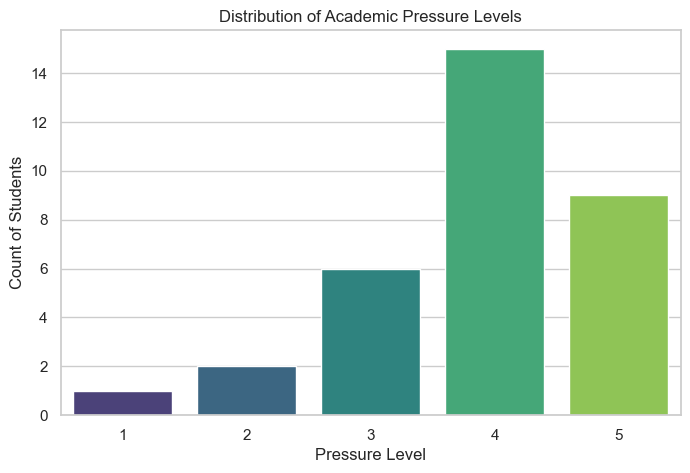

C:\Users\HP\AppData\Local\Temp\ipykernel_7348\2597328933.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Academic Pressure Level', y='Average Sleep Duration', palette='coolwarm')


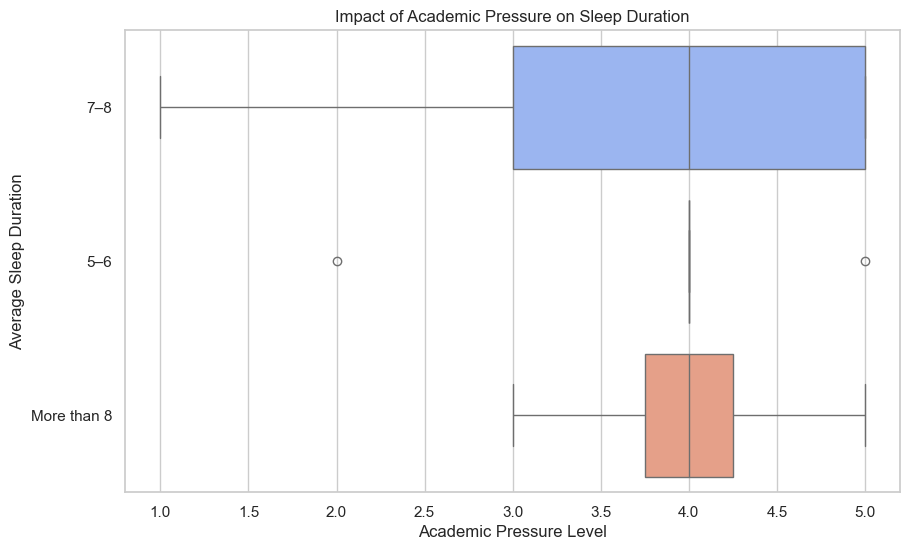

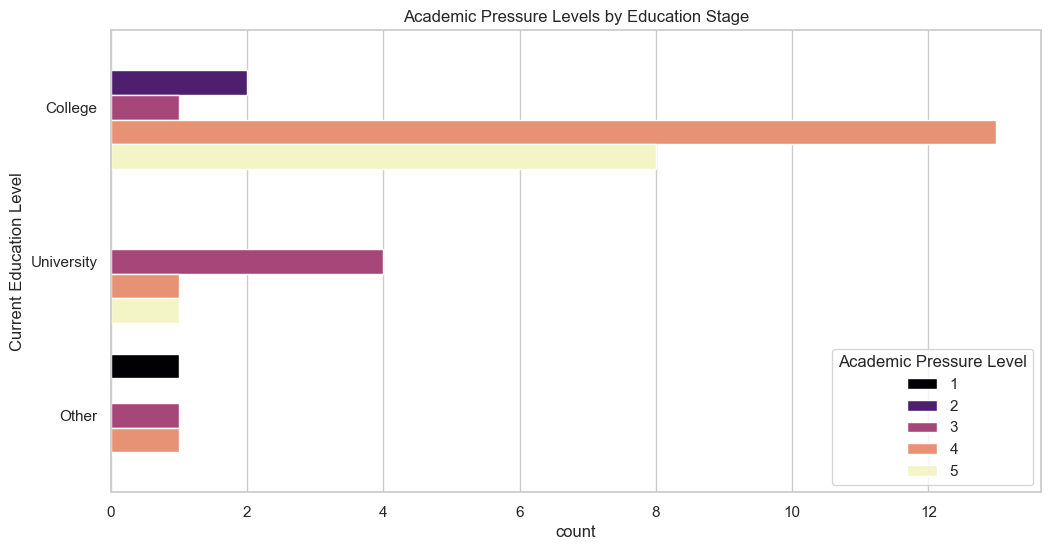

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style="whitegrid")

# Visualization 1: Distribution of Academic Pressure
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Academic Pressure Level', palette='viridis')
plt.title('Distribution of Academic Pressure Levels')
plt.xlabel('Pressure Level')
plt.ylabel('Count of Students')
plt.show()

# Visualization 2: Sleep Duration vs Academic Pressure
# Does less sleep mean more pressure?
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Academic Pressure Level', y='Average Sleep Duration', palette='coolwarm')
plt.title('Impact of Academic Pressure on Sleep Duration')
plt.show()

# Visualization 3: Stress by Education Level
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='Current Education Level', hue='Academic Pressure Level', palette='magma')
plt.title('Academic Pressure Levels by Education Stage')
plt.show()

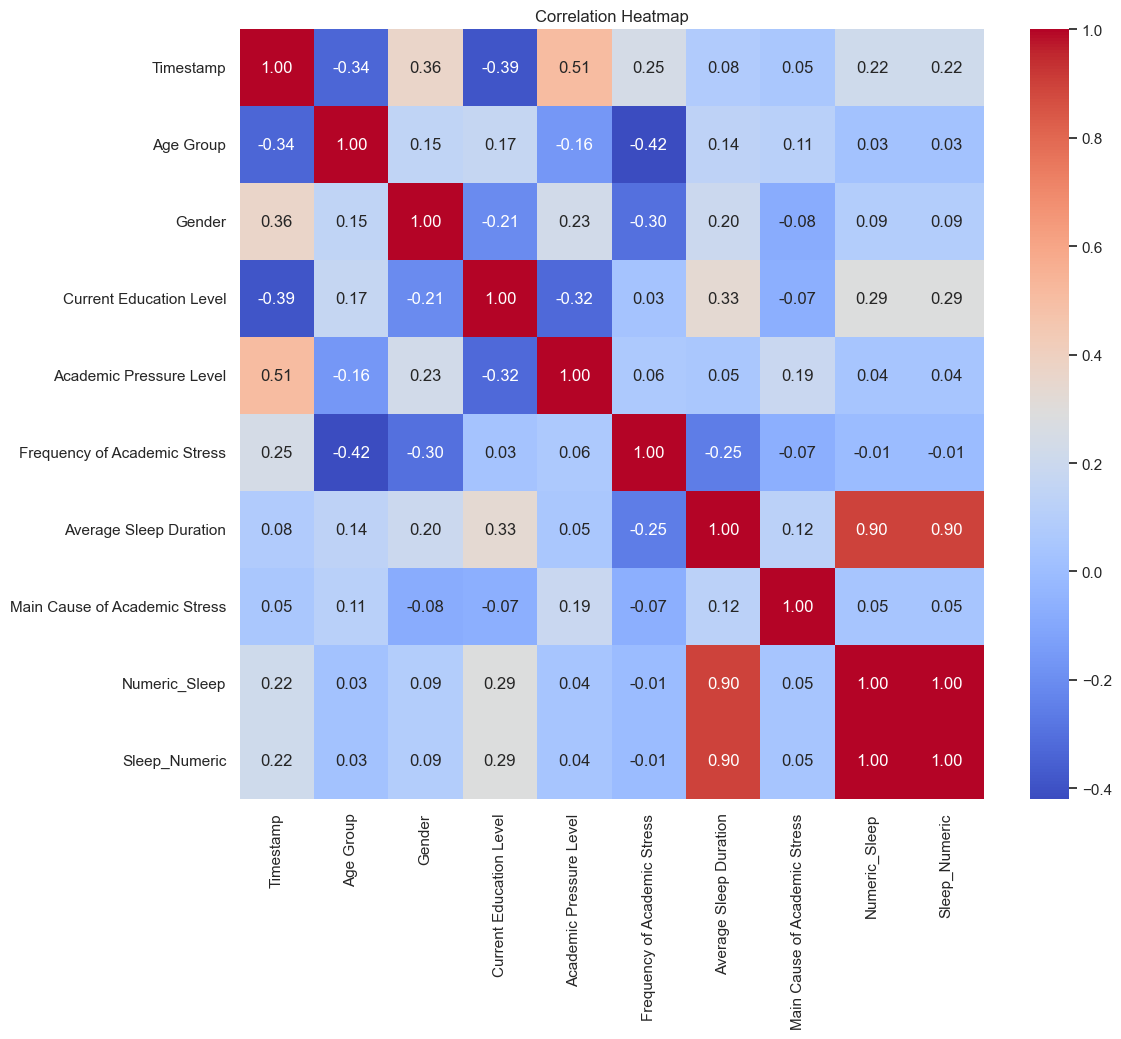


--- Average Pressure Level by Gender ---
Gender
Female    3.583333
Male      4.047619
Name: Academic Pressure Level, dtype: float64

--- Average Sleep Duration (Hours) based on Stress Frequency ---
Frequency of Academic Stress
Often        6.800000
Sometimes    7.309524
Always       7.428571
Name: Sleep_Numeric, dtype: float64


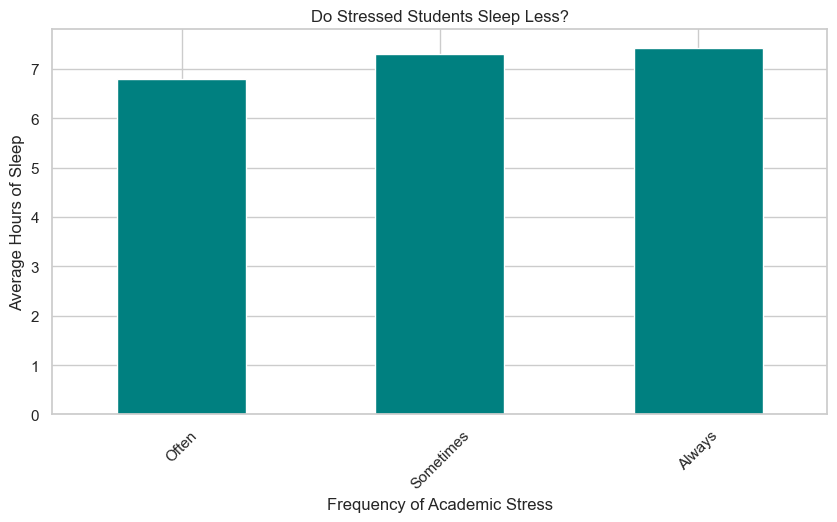

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import re

# --- STEP 1: CONVERT TEXT DATA TO NUMBERS ---

# Function to turn "5-6 hours" into the number 5.5
def clean_sleep_data(value):
    value = str(value) # Ensure it's text
    # Find all numbers in the text
    numbers = re.findall(r'\d+', value)
    if numbers:
        # Convert to integers
        numbers = [int(n) for n in numbers]
        # Calculate average (e.g., "5-6" becomes 5.5)
        return sum(numbers) / len(numbers)
    return None

# Apply this function to create a new numeric column
df['Sleep_Numeric'] = df['Average Sleep Duration'].apply(clean_sleep_data)

# Fill any empty values with the average sleep of the class
df['Sleep_Numeric'] = df['Sleep_Numeric'].fillna(df['Sleep_Numeric'].mean())

# --- STEP 2: PREPARE FOR CORRELATION ---

# Create a copy
df_calc = df.copy()

# Initialize encoder
le = LabelEncoder()

# Get all text columns (excluding our new numeric sleep column)
text_cols = df_calc.select_dtypes(include=['object']).columns

# Convert text to numbers for the correlation matrix
for col in text_cols:
    df_calc[col] = le.fit_transform(df_calc[col].astype(str))

# --- STEP 3: PERFORM ANALYSIS ---

# 1. Correlation Matrix
plt.figure(figsize=(12, 10))
# Calculate correlation on the DataFrame where everything is now a number
correlation = df_calc.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

# 2. Deep Insight: Average Pressure by Gender
# We use the original 'df' for the label, but ensure Pressure is numeric
df['Academic Pressure Level'] = pd.to_numeric(df['Academic Pressure Level'], errors='coerce')
pressure_by_gender = df.groupby('Gender')['Academic Pressure Level'].mean()

print("\n--- Average Pressure Level by Gender ---")
print(pressure_by_gender)

# 3. Deep Insight: Sleep vs Stress Frequency
# CRITICAL FIX: Use the 'Sleep_Numeric' column we created, not the text column
summary_table = df.groupby(['Frequency of Academic Stress'])['Sleep_Numeric'].mean()

print("\n--- Average Sleep Duration (Hours) based on Stress Frequency ---")
print(summary_table.sort_values())

# Bonus Visual: Plot this insight
plt.figure(figsize=(10,5))
summary_table.sort_values().plot(kind='bar', color='teal')
plt.title("Do Stressed Students Sleep Less?")
plt.ylabel("Average Hours of Sleep")
plt.xticks(rotation=45)
plt.show()